In [ ]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

In [30]:
# Dataset
import pandas as pd
file_path = "SAheart.csv"  # Replace with your CSV file path
df = pd.read_csv(file_path, sep=",", decimal=".")
print(df.head())


   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age chd
0  160    12.00  5.73      23.11  Present     49    25.30    97.20   52  Si
1  144     0.01  4.41      28.61   Absent     55    28.87     2.06   63  Si
2  118     0.08  3.48      32.28  Present     52    29.14     3.81   46  No
3  170     7.50  6.41      38.03  Present     51    31.99    24.26   58  Si
4  134    13.60  3.50      27.78  Present     60    25.99    57.34   49  Si


Characteristics The ten features are defined as follows:

sbp: systolic blood pressure

tobacco: cumulative tobacco (kg)

ldl: low density lipoprotein cholesterol

adiposity: the amount or distribution of fat tissue (adipose tissue) in the body

famhist: family history of heart disease (Present=1, Absent=0)

typea: type-A behavior

obesity: medical condition characterized by excessive body fat that may impair health

alcohol: current alcohol consumption

age: age at onset

chd: coronary heart disease (yes=1 or no=0)


In [90]:
# Include expert knowledge
from pgmpy.estimators import ExpertKnowledge
cols = list(df.columns)

# Forbid arrows OUT of chd: chd is the target variable
forbidden = [("chd", col) for col in cols if col != "chd"]

expert_knowledge = ExpertKnowledge(
    temporal_order=[
        ["age", "famhist"],   # upstream/background variables
        [c for c in cols if c not in ["age", "famhist", "chd"]],
        ["chd"]               # outcome last
    ],
    #forbidden_edges=forbidden,
)








  0%|          | 0/4 [00:00<?, ?it/s]






Working for n conditional variables: 0:   0%|          | 0/4 [00:00<?, ?it/s]/home/manzana/Data_Science/Uni/ML_Project/.venv/lib/python3.12/site-packages/pgmpy/estimators/BaseConstraintEstimator.py:236: FutureWarning: `pearsonr` is deprecated. Please use `pgmpy.ci_tests.Pearsonr` instead.
  if ci_test(
/home/manzana/Data_Science/Uni/ML_Project/.venv/lib/python3.12/site-packages/pgmpy/estimators/BaseConstraintEstimator.py:236: FutureWarning: `pearsonr` is deprecated. Please use `pgmpy.ci_tests.Pearsonr` instead.
  if ci_test(
/home/manzana/Data_Science/Uni/ML_Project/.venv/lib/python3.12/site-packages/pgmpy/estimators/BaseConstraintEstimator.py:236: FutureWarning: `pearsonr` is deprecated. Please use `pgmpy.ci_tests.Pearsonr` instead.
  if ci_test(
/home/manzana/Data_Science/Uni/ML_Project/.venv/lib/python3.12/site-packages/pgmpy/estimators/BaseConstraintEstimator.py:236: FutureWarning: `pearsonr` is deprecated. Please use `pgmpy.ci_tes

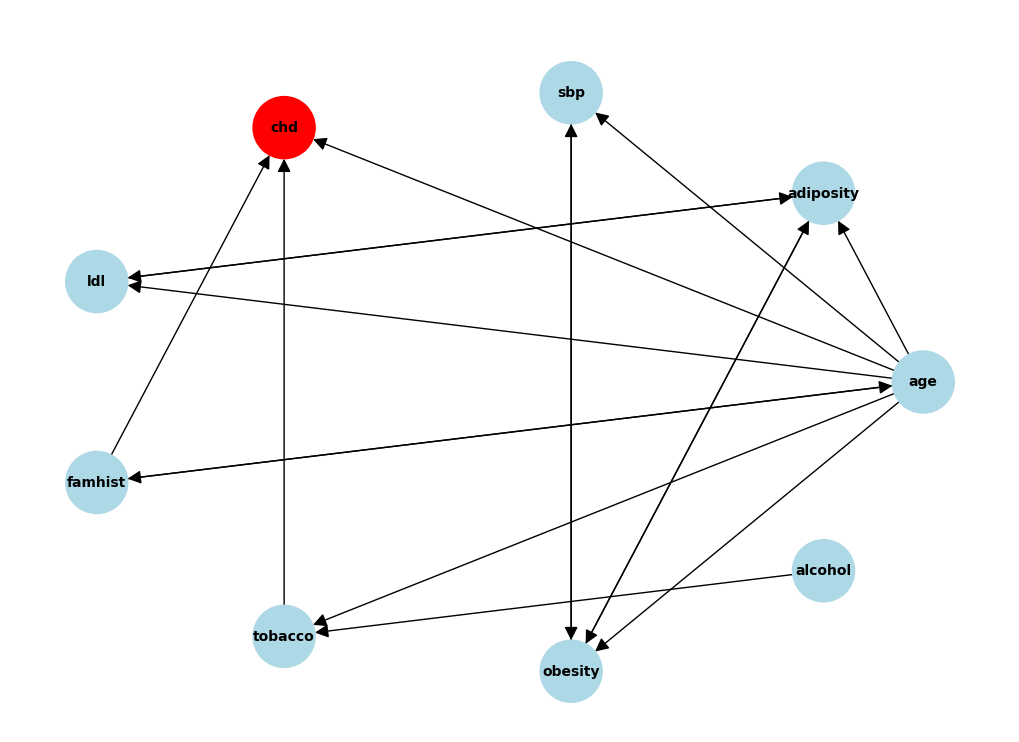

In [91]:
import pandas as pd
#from pgmpy.causal_discovery import PC
from pgmpy.estimators import PC
import networkx as nx
import matplotlib.pyplot as plt

def learn_dependency_graph(file_path,
                           max_cond_vars=2,
                           significance_level=0.01,
                           discretize_cont_cols = False,
                           expert_knowledge = None,
                           enforce_expert_knowledge = False,
                           debug = False):
    # Step 1: Load dataset
    data = pd.read_csv(file_path)

    data["famhist"] = data["famhist"].map({
        "Absent": 0,
        "Present": 1,
    })
    data["chd"] = data["chd"].map({
        "No": 0,
        "Si": 1,
    })

    # Optional: Discretize continuous columns
    if discretize_cont_cols:
        for col in data.select_dtypes(include=['float64', 'int64']).columns:
            data[col] = pd.qcut(data[col], q=4, duplicates='drop', labels=False)

    data.dropna(inplace=True)

    # Step 2: Estimate DAG with PC algorithm

    # Old version
    pc = PC(data)
    model = pc.estimate(significance_level=significance_level,
                        max_cond_vars=max_cond_vars,
                        #ci_test="chi_square" if discretize_cont_cols else "pearsonr",
                        #variant = "stable",
                        expert_knowledge=expert_knowledge,
                        enforce_expert_knowledge=enforce_expert_knowledge
                        )

    # New libary version
    # pc = PC(
    #     significance_level=significance_level,
    #     max_cond_vars=max_cond_vars,
    #     #ci_test="chi_square" if discretize_cont_cols else "pearsonr",
    #     #variant = "stable",
    #     expert_knowledge=expert_knowledge,
    #     enforce_expert_knowledge=enforce_expert_knowledge
    # )
    # pc.fit(data)
    # model = pc.causal_graph_

    # Step 3: Visualize the DAG using edges directly
    nx_graph = nx.DiGraph(model.edges())
    plt.figure(figsize=(10, 7))
    pos = nx.circular_layout(nx_graph)

    # Color nodes: red for 'chd', lightblue for others
    node_colors = ['red' if node == 'chd' else 'lightblue' for node in nx_graph.nodes()]

    nx.draw(nx_graph, pos, with_labels=True, node_size=2000, node_color=node_colors,
            font_size=10, font_weight="bold", arrowsize=20)
    plt.title("Dependency Graph Learned using PC Algorithm")
    plt.show()

    return model

# PC algorithm
learned_model = learn_dependency_graph(file_path,
                                       max_cond_vars=4,
                                       significance_level=0.01,
                                       expert_knowledge=expert_knowledge,
                                       enforce_expert_knowledge=True)